![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# **02 | Processing and Database Design**

### *Project 1 — SQL: From Data to Insight*

## **Team:** **Bright Jaato**

## **Dataset:** **CO<sub>2</sub> Reduction Electrocatalyst Dataset — Malek et al. (2021)**

---

Turning one flat file into a relational database: clean the data, split it into tables, wire up the keys, load it into SQLite.

> **Done when:** `data/project.db` exists with 3+ related tables, `sql/schema.sql` matches your ERD, no foreign key is dangling, and the row counts are what you expect.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.


## **Processing goal**

The goal of this notebook is to transform the raw CO<sub>2</sub>RR experimental data identified during exploratory data analysis into clean, consistent, and relationally structured data suitable for database creation and SQL analysis.

The processing decisions in this notebook are based on the data-quality issues identified in `01_eda.ipynb`. The original raw Excel workbook remains unchanged.

---
## **0. Setup**

### **Purpose**

This section loads the Python libraries and project utilities required for data cleaning, transformation, relational table creation, and later database construction.

The raw source data will not be modified directly. Cleaned DataFrames will be created separately.

In [1]:
# 1. Make the project root visible to Python.
# 2. Import the reusable cleaning and lookup functions.

import sys
sys.path.append("..")

from src.functions import clean_data, make_lookup

# Import libraries for data loading and transformation.
import pandas as pd
import numpy as np

# Import plotting libraries in case validation plots are needed.
import matplotlib.pyplot as plt
import seaborn as sns


# Allow pandas to display wide DataFrames more clearly.
pd.set_option("display.max_columns", 100)

# Use a clean plotting theme for any validation visualisations.
sns.set_theme(style="whitegrid")

---
## **1. Load the raw data**

### **Purpose**

The original Excel workbook is loaded again so that all processing begins from the unchanged raw source.

The two experimental data blocks identified during exploratory data analysis are extracted separately.

No cleaning or transformation is performed in this section.

First, define the file location.

In [2]:
# Import Path so the raw file location can be defined clearly.
from pathlib import Path

# Define the location of the original Excel workbook.
file_path = Path("../data/raw/Data Sheet.xlsx")

Next, load the two data blocks.

In [3]:
# Load the low-temperature experimental data block from columns E:L, using Excel row 4 as the column headers.
low_temp_df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    usecols="E:L",
    header=3
)

In [4]:
# Load the second experimental data block from columns O:U, using Excel row 4 as the column headers.

# The variable name high_temp_df is retained for continuity with Notebook 01, although EDA showed that this block
# contains both low- and high-temperature observations.
high_temp_df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    usecols="O:U",
    header=3
)

Verify the dimensions.

In [5]:
# Check the shapes of both imported DataFrames.
low_temp_df.shape, high_temp_df.shape

((181, 8), (181, 7))

Finally, inspect sample rows.

In [6]:
# Display the first five rows of the low-temperature dataset.
low_temp_df.head()

,Catalyst,Product,Cost ($/tCO2),Applied Potential (V),Faradaic Efficiency (%),Current Density (mA/cm2),Selectivity,Production Rate (m3/hr)
0,Cu,CO,1477.418,-0.68548,48.377360,685.9154,75.969040,5606.2650
1,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676,85.235440,3545.3830
2,Pt,CO,5169.764,-2.26996,92.883870,871.1595,1.876306,9569.3140
3,C,HCOOH,8467.830,-1.57404,95.451730,215.0477,45.157110,5870.4750
4,Pd,HCOOH,9688.819,-3.85536,70.355960,339.4034,37.265860,324.7051


In [7]:
# Display the first five rows of the second experimental dataset.
high_temp_df.head()

,Catalysts,Voltage(V),Jtot(mA/cm2),FE (%),Electrolyte,Product.1,T (oC)
0,Ni-YSZ,NaN,0.610727,100.0,YSZ,CO,850
1,Ni-YSZ,NaN,66.969819,100.0,YSZ,CO,850
2,Ni-YSZ,NaN,133.640737,100.0,YSZ,CO,850
3,Ni-YSZ,NaN,227.754773,100.0,YSZ,CO,850
4,Ni-YSZ,NaN,312.072820,100.0,YSZ,CO,850


### **Observation**

Both experimental data blocks were successfully loaded from the unchanged raw Excel workbook.

- The low-temperature DataFrame initially contains **181 rows and 8 columns**.
- The second experimental DataFrame contains **181 rows and 7 columns**.

As identified during EDA, the low-temperature DataFrame includes completely empty trailing rows, while the second experimental dataset contains 181 populated records.

The datasets will now be copied into separate working DataFrames before any cleaning is performed.

---
## **2. Clean**

The cleaning steps below address the data-quality issues identified during exploratory data analysis.

The original imported DataFrames are preserved unchanged. Separate working copies are created and cleaned instead.


First, create working copies of both datasets so the original imported DataFrames remain unchanged.

In [8]:
# 1. Take each original DataFrame.
# 2. Create a copy so the raw data remain unchanged.
# 3. Remove completely empty rows.
# 4. Remove leading/trailing spaces from text values.
# 5. Return the cleaned DataFrames.

low_temp_clean = clean_data(low_temp_df)
second_clean = clean_data(high_temp_df)

In [9]:
# 1. Check the dimensions of the cleaned datasets.
# 2. Confirm that completely empty low-temperature rows were removed.
# 3. Confirm that all populated records in the second dataset were preserved.

low_temp_clean.shape, second_clean.shape

((101, 8), (181, 7))

### **Observation**

First, create cleaned working copies of both datasets while keeping the original imported DataFrames unchanged.

The reusable `clean_data()` function removes completely empty rows and trims leading or trailing spaces from text values.

### **2.1 Clean the low-temperature dataset**

The EDA showed that the low-temperature dataset contained **80 completely empty trailing rows**.

These rows were already removed by the reusable `clean_data()` function at the start of Section 2.

The checks below confirm that the cleaned dataset now contains only populated experimental records.

In [10]:
# 1. Check the dimensions of the cleaned low-temperature dataset.
# 2. Confirm that 101 populated rows remain.

low_temp_clean.shape

(101, 8)

Next, verify that no completely empty rows remain in the cleaned dataset.

In [11]:
# 1. Check each row to see whether all values are missing.
# 2. Count how many fully empty rows remain.

low_temp_clean.isna().all(axis=1).sum()

0

#### **Observation**

The reusable cleaning function successfully removed the **80 completely empty trailing rows**.

The cleaned low-temperature dataset now contains **101 rows and 8 columns**, matching the populated experimental observations identified during EDA.

No completely empty rows remain.

#### **2.1.a Standardise column names**

Next, rename the columns using clear, consistent, and database-friendly names.

This makes the column names easier to use in Python and SQL.

In [12]:
# 1. Rename each original column.
# 2. Use lowercase snake_case names.
# 3. Keep units in the column names where useful.
# 4. Make the names suitable for Python and SQL.

low_temp_clean = low_temp_clean.rename(columns={
    "Catalyst": "catalyst",
    "Product": "product",
    "Cost ($/tCO2)": "cost_usd_per_tco2",
    "Applied Potential (V)": "applied_potential_v",
    "Faradaic Efficiency (%)": "faradaic_efficiency_pct",
    "Current Density (mA/cm2)": "current_density_ma_cm2",
    "Selectivity": "selectivity_pct",
    "Production Rate (m3/hr)": "production_rate_m3_hr"
})

Next, check the new column names to confirm that the renaming was successful.

In [13]:
# Display the cleaned column names to confirm that the renaming was successful.
low_temp_clean.columns.tolist()

['catalyst',
 'product',
 'cost_usd_per_tco2',
 'applied_potential_v',
 'faradaic_efficiency_pct',
 'current_density_ma_cm2',
 'selectivity_pct',
 'production_rate_m3_hr']

#### **Observation**

The low-temperature column names were standardised successfully.

The new names use consistent `snake_case` formatting and are easier to use in Python, SQL, and the relational database.

#### **2.1.b Clean categorical values**

Leading and trailing whitespace was already removed by the reusable `clean_data()` function.

Next, check the unique catalyst and product labels to confirm that the categories are clean and consistent.

In [14]:
# 1. Display the unique catalyst labels.
# 2. Display the unique product labels.
# 3. Confirm that no duplicate categories remain because of extra spaces.

low_temp_clean["catalyst"].unique(), low_temp_clean["product"].unique()

(array(['Cu', 'Pd', 'Pt', 'C', 'Au', 'Sn', 'Ir', 'Ag'], dtype=object),
 array(['CO', 'HCOOH', 'CH4', 'H2', 'C2H5OH'], dtype=object))

#### **Observation**

The cleaned low-temperature dataset contains **8 catalyst categories** and **5 product categories**.

The category labels are consistent, with no duplicate categories caused by leading or trailing whitespace.

#### **2.1.c Verify data types and missing values**

Next, confirm that each column has the expected data type and that no missing values remain in the cleaned low-temperature dataset.

In [15]:
# 1. Display the column names.
# 2. Check the data type of each column.
# 3. Check the number of non-missing values in each column.

low_temp_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   catalyst                 101 non-null    object 
 1   product                  101 non-null    object 
 2   cost_usd_per_tco2        101 non-null    float64
 3   applied_potential_v      101 non-null    float64
 4   faradaic_efficiency_pct  101 non-null    float64
 5   current_density_ma_cm2   101 non-null    float64
 6   selectivity_pct          101 non-null    float64
 7   production_rate_m3_hr    101 non-null    float64
dtypes: float64(6), object(2)
memory usage: 7.1+ KB


Next, count the missing values in each column to confirm that the cleaned dataset is complete.

In [16]:
# 1. Check each column for missing values.
# 2. Count how many missing values remain in each column.

low_temp_clean.isna().sum()

catalyst                   0
product                    0
cost_usd_per_tco2          0
applied_potential_v        0
faradaic_efficiency_pct    0
current_density_ma_cm2     0
selectivity_pct            0
production_rate_m3_hr      0
dtype: int64

#### **Observation**

The cleaned low-temperature dataset contains **101 complete records**.

The catalyst and product columns are stored as text, while the measurement columns are stored as numeric values.

No missing values remain in any column.

#### **2.1.d Final duplicate check**

Finally, check that the cleaned low-temperature dataset contains no exact duplicate experimental records.

In [17]:
# 1. Compare each row with all other rows.
# 2. Count how many exact duplicates exist.

low_temp_clean.duplicated().sum()

0

If duplicate rows exist, display them for inspection.

In [18]:
# Display duplicate rows, if any exist.

low_temp_clean[
    low_temp_clean.duplicated(keep=False)
]

,catalyst,product,cost_usd_per_tco2,applied_potential_v,faradaic_efficiency_pct,current_density_ma_cm2,selectivity_pct,production_rate_m3_hr


#### **Observation**

No exact duplicate records were found.

The cleaned low-temperature dataset therefore contains **101 unique and complete observations**.

This confirms that the cleaning steps did not create duplicate experimental records.

### **2.2 Clean the second experimental dataset**

The EDA identified three main issues in the second experimental dataset:

- inconsistent column names,
- leading/trailing whitespace in categorical values,
- structured missing values in voltage and Faradaic efficiency.

The reusable `clean_data()` function has already removed leading and trailing whitespace from text values.

The remaining steps standardise the column names and verify that the structured missing values are preserved correctly.

#### **2.2.a Standardise column names**

First, rename the columns using clear, consistent, and database-friendly names.

This makes the column names easier to use in Python, SQL, and the relational database.

In [19]:
# 1. Rename each original Excel column.
# 2. Use lowercase snake_case names.
# 3. Keep useful measurement units in the column names.
# 4. Make the names suitable for Python, SQL, and database use.

second_clean = second_clean.rename(columns={
    "Catalysts": "catalyst",
    "Voltage(V)": "voltage_v",
    "Jtot(mA/cm2)": "total_current_density_ma_cm2",
    "FE  (%)": "faradaic_efficiency_pct",
    "Electrolyte": "electrolyte",
    "Product.1": "product",
    "T (oC)": "temperature_c"
})

In [20]:
# Display the cleaned column names.

second_clean.columns.tolist()

['catalyst',
 'voltage_v',
 'total_current_density_ma_cm2',
 'faradaic_efficiency_pct',
 'electrolyte',
 'product',
 'temperature_c']

#### **Observation**

The column names in the second experimental dataset were standardised successfully.

The new names use consistent `snake_case` formatting and are suitable for Python, SQL, and the relational database.

#### **2.2.b Verification categorical values**

Leading and trailing whitespace was already removed by the reusable `clean_data()` function.

Next, check the unique catalyst, electrolyte, and product labels to confirm that the categories are clean and consistent.

In [21]:
# 1. Count the number of unique catalysts.
# 2. Count the number of unique electrolytes.
# 3. Count the number of unique products.
# 4. Confirm that whitespace cleaning consolidated duplicate labels.

second_clean["catalyst"].nunique(), \
second_clean["electrolyte"].nunique(), \
second_clean["product"].nunique()

(7, 7, 1)

Then inspect the cleaned labels:

In [22]:
# Display the cleaned unique catalyst labels.
second_clean["catalyst"].unique()

array(['Ni-YSZ', 'Ti', 'Ag/C', 'Ag', 'Ag-C', 'Au-MWCNT-PyPBI-Nafion-C',
       'Ag-MWCNT-Nafion'], dtype=object)

In [23]:
# Display the cleaned unique electrolyte labels.
second_clean["electrolyte"].unique()

array(['YSZ', 'CGO-YSZ', 'Li2O-Li2CO3', 'KOH-Nafion-K2SO4',
       'KHCO3-Sustanion-PTFE', 'KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3', 'KOH'],
      dtype=object)

In [24]:
# Display the cleaned unique product labels.
second_clean["product"].unique()

array(['CO'], dtype=object)

#### **Observation**

The cleaned second experimental dataset contains:

- **7 catalyst categories**
- **7 electrolyte categories**
- **1 product category (`CO`)**

The catalyst count decreased from 8 raw labels to 7 cleaned categories, confirming that one duplicate label was caused only by extra whitespace.

No scientifically distinct catalyst labels were merged.

#### **2.2.c Preserve structured missing values**

Next, verify the missing-value pattern in the second experimental dataset.

The missing values in `voltage_v` and `faradaic_efficiency_pct` follow a structured reporting pattern, so they should be preserved rather than removed or filled in.

In [25]:
# 1. Count missing values in every column.
# 2. Identify which columns contain missing values.
# 3. Confirm that the other columns are complete.

second_clean.columns.tolist()

['catalyst',
 'voltage_v',
 'total_current_density_ma_cm2',
 'faradaic_efficiency_pct',
 'electrolyte',
 'product',
 'temperature_c']

Next, check whether voltage and Faradaic efficiency are missing in a complementary pattern.

In [26]:
# 1. Count rows where voltage is missing but FE is present.
# 2. Count rows where FE is missing but voltage is present.
# 3. Count rows where both are missing.
# 4. Count rows where both are present.

voltage_missing_fe_present = (
    second_clean["voltage_v"].isna() &
    second_clean["faradaic_efficiency_pct"].notna()
).sum()

fe_missing_voltage_present = (
    second_clean["faradaic_efficiency_pct"].isna() &
    second_clean["voltage_v"].notna()
).sum()

both_missing = (
    second_clean["voltage_v"].isna() &
    second_clean["faradaic_efficiency_pct"].isna()
).sum()

both_present = (
    second_clean["voltage_v"].notna() &
    second_clean["faradaic_efficiency_pct"].notna()
).sum()

print("Voltage missing, FE present:", voltage_missing_fe_present)
print("FE missing, voltage present:", fe_missing_voltage_present)
print("Both missing:", both_missing)
print("Both present:", both_present)

Voltage missing, FE present: 105
FE missing, voltage present: 76
Both missing: 0
Both present: 0


#### **Observation**

The second experimental dataset contains a structured missing-value pattern:

- **105 rows** have Faradaic efficiency reported but no voltage.
- **76 rows** have voltage reported but no Faradaic efficiency.
- **0 rows** have both values missing.
- **0 rows** have both values present.

Because every row contains either voltage or Faradaic efficiency, these missing values are preserved without imputation or row deletion.

#### **2.2.d Verify data types and duplicates**

Finally, confirm that the cleaned second experimental dataset has the expected data types and contains no exact duplicate records.

In [27]:
# 1. Display the column names.
# 2. Check the data type of each column.
# 3. Check the number of non-missing values in each column.

second_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   catalyst                      181 non-null    object 
 1   voltage_v                     76 non-null     float64
 2   total_current_density_ma_cm2  181 non-null    float64
 3   faradaic_efficiency_pct       105 non-null    float64
 4   electrolyte                   181 non-null    object 
 5   product                       181 non-null    object 
 6   temperature_c                 181 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 10.0+ KB


Next, count exact duplicate rows in the cleaned dataset.

In [28]:
# 1. Compare each row with all other rows.
# 2. Count how many exact duplicates exist.

second_clean.duplicated().sum()

0

If duplicate rows exist, display them for inspection.

In [29]:
# Display any duplicate rows if they exist.
second_clean[
    second_clean.duplicated(keep=False)
]

,catalyst,voltage_v,total_current_density_ma_cm2,faradaic_efficiency_pct,electrolyte,product,temperature_c


#### **Observation**

The cleaned second experimental dataset contains **181 records and 7 columns**.

The text columns are stored as categorical text values, while the numerical measurement columns are stored as numeric data.

The structured missing values in `voltage_v` and `faradaic_efficiency_pct` are preserved as expected.

No exact duplicate records were found.

### **2.3 Validate the cleaned datasets**

Before designing the relational database, perform one final validation of both cleaned datasets.

The summary below checks the final dimensions, total missing values, and duplicate counts.

In [30]:
# Create a summary showing the final size, total missing values, and duplicate rows in each cleaned dataset.
validation_summary = pd.DataFrame({
    "dataset": [
        "Low-temperature dataset",
        "Second experimental dataset"
    ],
    "rows": [
        low_temp_clean.shape[0],
        second_clean.shape[0]
    ],
    "columns": [
        low_temp_clean.shape[1],
        second_clean.shape[1]
    ],
    "missing_values": [
        low_temp_clean.isna().sum().sum(),
        second_clean.isna().sum().sum()
    ],
    "duplicate_rows": [
        low_temp_clean.duplicated().sum(),
        second_clean.duplicated().sum()
    ]
})

validation_summary

,dataset,rows,columns,missing_values,duplicate_rows
0,Low-temperature dataset,101,8,0,0
1,Second experimental dataset,181,7,181,0


#### **Observation**

The final validation confirms that:

- the low-temperature dataset contains **101 rows and 8 columns**
- the second experimental dataset contains **181 rows and 7 columns**
- no exact duplicate rows are present in either dataset
- the low-temperature dataset has no missing values
- the second dataset contains **181 expected missing cells**, caused by the structured voltage/Faradaic-efficiency reporting pattern

The cleaned datasets are therefore ready for relational database design.

### **2.4 Inspect the final cleaned datasets**

Finally, display a small sample of both cleaned datasets to confirm that the values and structure look as expected.

In [31]:
# Display the first five rows of the cleaned low-temperature dataset.
low_temp_clean.head()

,catalyst,product,cost_usd_per_tco2,applied_potential_v,faradaic_efficiency_pct,current_density_ma_cm2,selectivity_pct,production_rate_m3_hr
0,Cu,CO,1477.418,-0.68548,48.377360,685.9154,75.969040,5606.2650
1,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676,85.235440,3545.3830
2,Pt,CO,5169.764,-2.26996,92.883870,871.1595,1.876306,9569.3140
3,C,HCOOH,8467.830,-1.57404,95.451730,215.0477,45.157110,5870.4750
4,Pd,HCOOH,9688.819,-3.85536,70.355960,339.4034,37.265860,324.7051


In [32]:
# Display the first five rows of the cleaned second experimental dataset.
second_clean.head()

,catalyst,voltage_v,total_current_density_ma_cm2,faradaic_efficiency_pct,electrolyte,product,temperature_c
0,Ni-YSZ,NaN,0.610727,100.0,YSZ,CO,850
1,Ni-YSZ,NaN,66.969819,100.0,YSZ,CO,850
2,Ni-YSZ,NaN,133.640737,100.0,YSZ,CO,850
3,Ni-YSZ,NaN,227.754773,100.0,YSZ,CO,850
4,Ni-YSZ,NaN,312.072820,100.0,YSZ,CO,850


#### **Observation**

Both cleaned datasets show the expected column structure and cleaned categorical values.

The datasets are ready for relational database design.

---
## **3. Design the relational tables**

The cleaned datasets contain repeated categorical values such as catalysts, products, and electrolytes.

To reduce repeated text and create clear relationships between the data, the cleaned datasets are reorganised into relational tables.

The design separates repeated categories from experimental measurements so the data can be stored and queried efficiently.

### **3.1 Identify the main entities**

First, identify the main entities that should be stored as separate database tables.

The following five tables are used:

1. `catalysts`
   - stores each unique catalyst once.

2. `products`
   - stores each unique CO<sub>2</sub>RR product once.

3. `electrolytes`
   - stores each unique electrolyte once.

4. `low_temp_experiments`
   - stores the measurements from the low-temperature dataset.

5. `second_experiments`
   - stores the measurements from the second experimental dataset.

### **3.2 Define primary and foreign keys**

Next, define the primary key for each table and the foreign keys that connect the experiment tables to the lookup tables.

#### **Primary keys**

A primary key uniquely identifies each row in a table.

The primary keys are:

- `catalyst_id` for `catalysts`
- `product_id` for `products`
- `electrolyte_id` for `electrolytes`
- `experiment_id` for `low_temp_experiments`
- `experiment_id` for `second_experiments`

#### **Foreign keys**

A foreign key connects one table to another by referencing the primary key of a related table.

`low_temp_experiments` contains:

- `catalyst_id` → references `catalysts.catalyst_id`
- `product_id` → references `products.product_id`

`second_experiments` contains:

- `catalyst_id` → references `catalysts.catalyst_id`
- `product_id` → references `products.product_id`
- `electrolyte_id` → references `electrolytes.electrolyte_id`

#### **Table 1. Relational tables and key relationships**

| Table | Primary key | Foreign keys |
|---|---|---|
| `catalysts` | `catalyst_id` | — |
| `products` | `product_id` | — |
| `electrolytes` | `electrolyte_id` | — |
| `low_temp_experiments` | `experiment_id` | `catalyst_id`, `product_id` |
| `second_experiments` | `experiment_id` | `catalyst_id`, `product_id`, `electrolyte_id` |

### **3.3 Define the table columns**

Next, specify which fields belong in each relational table before creating the ERD and database schema.

#### **Table 2. Columns in each relational table**

| Table | Columns |
|---|---|
| `catalysts` | `catalyst_id`, `catalyst_name` |
| `products` | `product_id`, `product_name` |
| `electrolytes` | `electrolyte_id`, `electrolyte_name` |
| `low_temp_experiments` | `experiment_id`, `catalyst_id`, `product_id`, `cost_usd_per_tco2`, `applied_potential_v`, `faradaic_efficiency_pct`, `current_density_ma_cm2`, `selectivity_pct`, `production_rate_m3_hr` |
| `second_experiments` | `experiment_id`, `catalyst_id`, `product_id`, `electrolyte_id`, `voltage_v`, `total_current_density_ma_cm2`, `faradaic_efficiency_pct`, `temperature_c` |

The lookup tables store the unique categorical values and their IDs.

The experiment tables store the measurements and the foreign keys that connect each experimental record to the relevant catalyst, product, and electrolyte.

This structure reduces repeated categorical text and makes the data easier to join and analyse with SQL.

### **3.4 Define table relationships**

Next, define how the tables are connected and the cardinality of each relationship.

#### Table 3. Relationships and cardinality

| Parent table | Child table | Relationship |
|---|---|---|
| `catalysts` | `low_temp_experiments` | One-to-many |
| `products` | `low_temp_experiments` | One-to-many |
| `catalysts` | `second_experiments` | One-to-many |
| `products` | `second_experiments` | One-to-many |
| `electrolytes` | `second_experiments` | One-to-many |

A one-to-many relationship means that one record in a lookup table can be linked to many experimental records.

For example, one catalyst such as `Cu` can appear in many rows of `low_temp_experiments`, while each experimental row refers to only one catalyst through `catalyst_id`.

The same logic applies to products and electrolytes.

### **3.5 Entity Relationship Diagram (ERD)**

Based on the final tables, primary keys, foreign keys, and relationships, the database can be represented using the following relational structure.

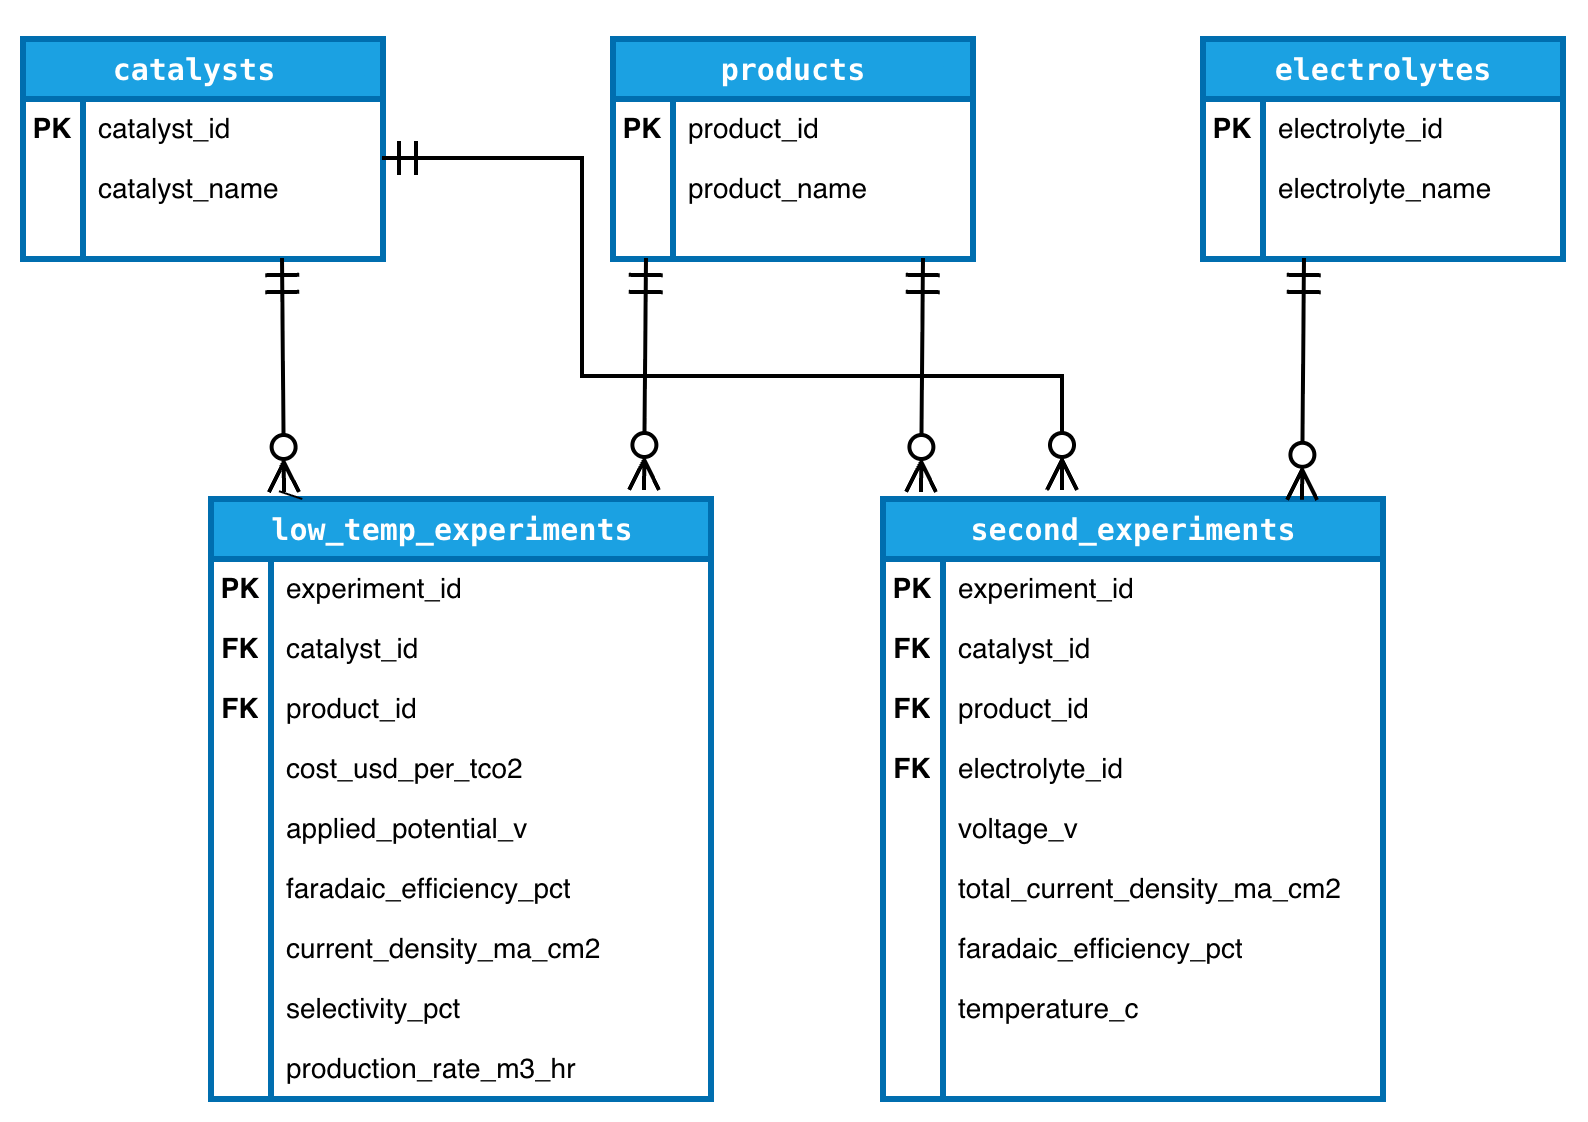

#### **Interpretation**

The ERD contains three lookup tables:

- `catalysts`
- `products`
- `electrolytes`

and two experiment tables:

- `low_temp_experiments`
- `second_experiments`

Each lookup table can be linked to many experimental records, while each experimental record refers to one related catalyst, product, or electrolyte through a foreign key.

This structure reduces repeated categorical information and supports efficient SQL joins.

---
## **4. Build the relational tables**

### **4.1 Create the `catalysts` lookup table**

First, combine the catalyst labels from both cleaned datasets into one temporary table.

This allows the same catalyst to be represented only once in the final lookup table.

In [33]:
# 1. Take catalyst names from the low-temperature dataset.
# 2. Take catalyst names from the second experimental dataset.
# 3. Combine both sets of names.
# 4. Store them in one temporary DataFrame.

all_catalysts = pd.concat(
    [
        low_temp_clean["catalyst"],
        second_clean["catalyst"]
    ],
    ignore_index=True
).to_frame(name="catalyst_name")

all_catalysts.head()

,catalyst_name
0,Cu
1,Pd
2,Pt
3,C
4,Pd


Next, create the final catalyst lookup table.

The reusable `make_lookup()` function keeps each catalyst only once, sorts the names, and assigns a unique `catalyst_id`.

In [34]:
# 1. Read the combined catalyst names.
# 2. Remove repeated catalyst names.
# 3. Sort the unique catalyst names.
# 4. Assign a unique numerical catalyst_id.
# 5. Return the final lookup table.

catalysts = make_lookup(
    all_catalysts,
    column="catalyst_name",
    id_column="catalyst_id"
)

catalysts

,catalyst_id,catalyst_name
0,1,Ag
1,2,Ag-C
2,3,Ag-MWCNT-Nafion
3,4,Ag/C
4,5,Au
5,6,Au-MWCNT-PyPBI-Nafion-C
6,7,C
7,8,Cu
8,9,Ir
9,10,Ni-YSZ


Next, verify that both the primary-key values and catalyst names are unique.

In [35]:
# Check that every catalyst_id is unique.
catalysts["catalyst_id"].is_unique

True

In [36]:
# Check that every catalyst name appears only once.
catalysts["catalyst_name"].is_unique

True

#### **Observation**

The `catalysts` lookup table contains one row for each unique catalyst appearing across the two cleaned datasets.

Each catalyst has a unique `catalyst_id`, which will serve as the primary key.

No duplicate catalyst names remain in the lookup table.

### **4.2 Create the `products` lookup table**

Next, combine the product labels from both cleaned datasets into one temporary table.

The reusable `make_lookup()` function will then keep each product only once and assign a unique `product_id`.

In [37]:
# 1. Take product names from the low-temperature dataset.
# 2. Take product names from the second experimental dataset.
# 3. Combine both sets of names.
# 4. Store them in one temporary DataFrame.

all_products = pd.concat(
    [
        low_temp_clean["product"],
        second_clean["product"]
    ],
    ignore_index=True
).to_frame(name="product_name")

all_products.head()

,product_name
0,CO
1,HCOOH
2,CO
3,HCOOH
4,HCOOH


Next, create the final product lookup table.

The `make_lookup()` function removes repeated product names, sorts them, and assigns a unique `product_id`.

In [38]:
# 1. Read the combined product names.
# 2. Remove repeated product names.
# 3. Sort the unique products.
# 4. Assign a unique product_id.
# 5. Return the final lookup table.

products = make_lookup(
    all_products,
    column="product_name",
    id_column="product_id"
)

products

,product_id,product_name
0,1,C2H5OH
1,2,CH4
2,3,CO
3,4,H2
4,5,HCOOH


Next, verify that both the product IDs and product names are unique.

In [39]:
# Check that every product_id is unique.
products["product_id"].is_unique

True

In [40]:
# Check that every product name appears only once.
products["product_name"].is_unique

True

#### **Observation**

The `products` lookup table contains **5 unique CO<sub>2</sub>RR products** from the two cleaned datasets.

Each product has a unique `product_id`, which will serve as the primary key.

No duplicate product names remain in the lookup table.

### **4.3 Create the `electrolytes` lookup table**

Next, take the electrolyte labels from the cleaned second experimental dataset and store them in a temporary table.

The reusable `make_lookup()` function will then keep each electrolyte only once and assign a unique `electrolyte_id`.

In [41]:
# 1. Take the electrolyte column from the second cleaned dataset.
# 2. Store the values in a temporary DataFrame.
# 3. Keep the original cleaned labels unchanged.

all_electrolytes = second_clean[["electrolyte"]].rename(
    columns={"electrolyte": "electrolyte_name"}
)

all_electrolytes.head()

,electrolyte_name
0,YSZ
1,YSZ
2,YSZ
3,YSZ
4,YSZ


Next, create the final electrolyte lookup table.

The `make_lookup()` function removes repeated electrolyte names, sorts them, and assigns a unique `electrolyte_id`.

In [42]:
# 1. Read the electrolyte names.
# 2. Remove repeated electrolyte names.
# 3. Sort the unique electrolytes.
# 4. Assign a unique electrolyte_id.
# 5. Return the final lookup table.

electrolytes = make_lookup(
    all_electrolytes,
    column="electrolyte_name",
    id_column="electrolyte_id"
)

electrolytes

,electrolyte_id,electrolyte_name
0,1,CGO-YSZ
1,2,KHCO3-Sustanion-PTFE
2,3,KK2SO4-KHCO3-ZrO2-K2SO4-KHCO3
3,4,KOH
4,5,KOH-Nafion-K2SO4
5,6,Li2O-Li2CO3
6,7,YSZ


Next, verify that both the electrolyte IDs and electrolyte names are unique.

In [43]:
# Check that every electrolyte_id is unique.
electrolytes["electrolyte_id"].is_unique

True

In [44]:
# Check that every electrolyte name appears only once.
electrolytes["electrolyte_name"].is_unique

True

#### **Observation**

The `electrolytes` lookup table contains **7 unique electrolyte categories** from the second experimental dataset.

Each electrolyte has a unique `electrolyte_id`, which will serve as the primary key.

No duplicate electrolyte names remain in the lookup table.

### **4.4 Create the `low_temp_experiments` table**

Next, convert the cleaned low-temperature dataset into a relational experiment table.

The catalyst and product names are replaced with their corresponding lookup-table IDs so that the final table uses foreign keys instead of repeated categorical text.

In [45]:
# 1. Start again from the cleaned low-temperature dataset.
# 2. Add catalyst_id by joining with the catalysts lookup table.
# 3. Add product_id by joining with the products lookup table.
# 4. Check that both foreign-key columns now exist.

low_temp_experiments = low_temp_clean.copy()

# Add catalyst_id.
low_temp_experiments = low_temp_experiments.merge(
    catalysts,
    left_on="catalyst",
    right_on="catalyst_name",
    how="left"
)

# Add product_id.
low_temp_experiments = low_temp_experiments.merge(
    products,
    left_on="product",
    right_on="product_name",
    how="left"
)

low_temp_experiments.columns.tolist()

['catalyst',
 'product',
 'cost_usd_per_tco2',
 'applied_potential_v',
 'faradaic_efficiency_pct',
 'current_density_ma_cm2',
 'selectivity_pct',
 'production_rate_m3_hr',
 'catalyst_id',
 'catalyst_name',
 'product_id',
 'product_name']

Both lookup-table IDs have now been added.

Next, keep only the foreign keys and experimental measurement columns required for the final relational table.

Next, match each product name with the products lookup table and add the corresponding `product_id`.

In [46]:
# 1. Keep the catalyst_id and product_id foreign keys.
# 2. Keep all experimental measurement columns.
# 3. Remove the repeated catalyst and product text labels.

low_temp_experiments = low_temp_experiments[
    [
        "catalyst_id",
        "product_id",
        "cost_usd_per_tco2",
        "applied_potential_v",
        "faradaic_efficiency_pct",
        "current_density_ma_cm2",
        "selectivity_pct",
        "production_rate_m3_hr"
    ]
]

Next, assign a unique `experiment_id` to each experimental record.

In [47]:
# 1. Create sequential experiment IDs.
# 2. Insert experiment_id as the first column.
# 3. Use experiment_id as the primary key.

low_temp_experiments.insert(
    0,
    "experiment_id",
    range(1, len(low_temp_experiments) + 1)
)

low_temp_experiments.head()

,experiment_id,catalyst_id,product_id,cost_usd_per_tco2,applied_potential_v,faradaic_efficiency_pct,current_density_ma_cm2,selectivity_pct,production_rate_m3_hr
0,1,8,3,1477.418,-0.68548,48.377360,685.9154,75.969040,5606.2650
1,2,11,5,3189.148,-1.13664,2.602357,203.6676,85.235440,3545.3830
2,3,12,3,5169.764,-2.26996,92.883870,871.1595,1.876306,9569.3140
3,4,7,5,8467.830,-1.57404,95.451730,215.0477,45.157110,5870.4750
4,5,11,5,9688.819,-3.85536,70.355960,339.4034,37.265860,324.7051


Finally, verify that all 101 records were preserved, that every foreign key was assigned successfully, and that each `experiment_id` is unique.

In [48]:
# Confirm that all 101 experimental records were preserved.
low_temp_experiments.shape

(101, 9)

In [49]:
# Check that no catalyst_id or product_id values are missing.

low_temp_experiments[
    ["catalyst_id", "product_id"]
].isna().sum()

catalyst_id    0
product_id     0
dtype: int64

In [50]:
# Verify that experiment_id uniquely identifies every row.
low_temp_experiments["experiment_id"].is_unique

True

#### **Observation**

The `low_temp_experiments` table contains **101 experimental records**.

Each record has a unique `experiment_id`, a valid `catalyst_id`, and a valid `product_id`.

No foreign-key values are missing, and all cleaned low-temperature observations were preserved.

The table is ready to be loaded into the relational database.

### **4.5 Create the `second_experiments` table**

Next, replace the repeated catalyst, product, and electrolyte names in the cleaned second experimental dataset with their corresponding lookup-table IDs.

This creates a database-ready experiment table that uses foreign keys instead of repeated categorical text.

In [51]:
# 1. Start from the cleaned second experimental dataset.
# 2. Match each catalyst name with the catalysts lookup table.
# 3. Add the corresponding catalyst_id.

second_experiments = second_clean.merge(
    catalysts,
    left_on="catalyst",
    right_on="catalyst_name",
    how="left"
)

Next, match each product name with the products lookup table and add the corresponding `product_id`.

In [52]:
# 1. Take the current experiment table.
# 2. Match each product name with the products lookup table.
# 3. Add the corresponding product_id.

second_experiments = second_experiments.merge(
    products,
    left_on="product",
    right_on="product_name",
    how="left"
)

Next, match each electrolyte name with the electrolytes lookup table and add the corresponding `electrolyte_id`.

In [53]:
# 1. Take the current experiment table.
# 2. Match each electrolyte name with the electrolytes lookup table.
# 3. Add the corresponding electrolyte_id.

second_experiments = second_experiments.merge(
    electrolytes,
    left_on="electrolyte",
    right_on="electrolyte_name",
    how="left"
)

Next, remove the repeated categorical text labels and keep only the foreign-key IDs together with the experimental measurements.

In [54]:
# 1. Keep the catalyst_id, product_id, and electrolyte_id foreign keys.
# 2. Keep all experimental measurement columns.
# 3. Remove the repeated text labels.

second_experiments = second_experiments[
    [
        "catalyst_id",
        "product_id",
        "electrolyte_id",
        "voltage_v",
        "total_current_density_ma_cm2",
        "faradaic_efficiency_pct",
        "temperature_c"
    ]
]

Next, assign a unique `experiment_id` to each experimental record.

In [55]:
# 1. Create sequential experiment IDs.
# 2. Insert experiment_id as the first column.
# 3. Use it as the primary key for this table.

second_experiments.insert(
    0,
    "experiment_id",
    range(1, len(second_experiments) + 1)
)

second_experiments.head()

,experiment_id,catalyst_id,product_id,electrolyte_id,voltage_v,total_current_density_ma_cm2,faradaic_efficiency_pct,temperature_c
0,1,10,3,7,NaN,0.610727,100.0,850
1,2,10,3,7,NaN,66.969819,100.0,850
2,3,10,3,7,NaN,133.640737,100.0,850
3,4,10,3,7,NaN,227.754773,100.0,850
4,5,10,3,7,NaN,312.072820,100.0,850


Finally, verify that all 181 records were preserved, all foreign keys were assigned correctly, and the original structured missing-value pattern remains unchanged.

In [56]:
# Confirm that all 181 records were preserved.
second_experiments.shape

(181, 8)

In [57]:
# Check that every record has valid foreign-key IDs.

second_experiments[
    ["catalyst_id", "product_id", "electrolyte_id"]
].isna().sum()

catalyst_id       0
product_id        0
electrolyte_id    0
dtype: int64

In [58]:
# Verify that experiment_id uniquely identifies every row.

second_experiments["experiment_id"].is_unique

True

In [59]:
# Confirm that the structured missing values remain unchanged.

second_experiments[
    ["voltage_v", "faradaic_efficiency_pct"]
].isna().sum()

voltage_v                  105
faradaic_efficiency_pct     76
dtype: int64

#### **Observation**

The `second_experiments` table contains **181 experimental records**.

Each record has:

- a unique `experiment_id`
- a valid `catalyst_id`
- a valid `product_id`
- a valid `electrolyte_id`

No foreign-key values are missing.

The original structured missing-value pattern was also preserved, with **105 missing voltage values** and **76 missing Faradaic-efficiency values**.

The table is ready to be loaded into the relational database.

---
## **5. Check the foreign keys**

Before creating the SQLite database, verify that every foreign-key value in the experiment tables exists in the corresponding lookup table.

This prevents invalid references and helps ensure that later SQL joins do not silently lose rows.

First, check the foreign keys in `low_temp_experiments`.

In [60]:
# 1. Check every catalyst_id in low_temp_experiments.
# 2. Confirm that each ID exists in the catalysts lookup table.
# 3. Check every product_id in low_temp_experiments.
# 4. Confirm that each ID exists in the products lookup table.

invalid_low_catalyst_fk = (
    ~low_temp_experiments["catalyst_id"]
    .isin(catalysts["catalyst_id"])
).sum()

invalid_low_product_fk = (
    ~low_temp_experiments["product_id"]
    .isin(products["product_id"])
).sum()

invalid_low_catalyst_fk, invalid_low_product_fk

(0, 0)

Next, check the foreign keys in `second_experiments`.

In [61]:
# 1. Check every catalyst_id.
# 2. Check every product_id.
# 3. Check every electrolyte_id.
# 4. Confirm that all IDs exist in their lookup tables.

invalid_second_catalyst_fk = (
    ~second_experiments["catalyst_id"]
    .isin(catalysts["catalyst_id"])
).sum()

invalid_second_product_fk = (
    ~second_experiments["product_id"]
    .isin(products["product_id"])
).sum()

invalid_second_electrolyte_fk = (
    ~second_experiments["electrolyte_id"]
    .isin(electrolytes["electrolyte_id"])
).sum()

invalid_second_catalyst_fk, \
invalid_second_product_fk, \
invalid_second_electrolyte_fk

(0, 0, 0)

#### **Observation**

All foreign-key checks returned **0 invalid references**.

This confirms that:

- every `catalyst_id` exists in `catalysts`
- every `product_id` exists in `products`
- every `electrolyte_id` exists in `electrolytes`

The relational tables are therefore consistent and ready for SQLite database creation.

### **5.1 Final relational table summary**

Finally, summarise the size of each relational table before creating the SQLite database.

This provides a final check that all lookup tables and experiment tables were created with the expected number of rows and columns.

In [62]:
# 1. List the five final relational tables.
# 2. Record the number of rows in each table.
# 3. Record the number of columns in each table.
# 4. Display the summary in one DataFrame.

relational_summary = pd.DataFrame({
    "table": [
        "catalysts",
        "products",
        "electrolytes",
        "low_temp_experiments",
        "second_experiments"
    ],
    "rows": [
        catalysts.shape[0],
        products.shape[0],
        electrolytes.shape[0],
        low_temp_experiments.shape[0],
        second_experiments.shape[0]
    ],
    "columns": [
        catalysts.shape[1],
        products.shape[1],
        electrolytes.shape[1],
        low_temp_experiments.shape[1],
        second_experiments.shape[1]
    ]
})

relational_summary

,table,rows,columns
0,catalysts,14,2
1,products,5,2
2,electrolytes,7,2
3,low_temp_experiments,101,9
4,second_experiments,181,8


#### **Observation**

The final relational structure contains five tables:

- `catalysts`: **14 rows and 2 columns**
- `products`: **5 rows and 2 columns**
- `electrolytes`: **7 rows and 2 columns**
- `low_temp_experiments`: **101 rows and 9 columns**
- `second_experiments`: **181 rows and 8 columns**

The lookup tables contain the unique categorical values, while the experiment tables contain the experimental measurements and foreign keys.

The relational tables are now ready to be saved and loaded into SQLite.

---
## **6. Save the processed relational tables**

After validating the relational structure, save each final table as a CSV file in the `data/clean/` folder.

These files are the cleaned, reproducible outputs of the processing stage and can be used to recreate or inspect the relational database.

First, define the output folder and create it if it does not already exist.

In [63]:
# 1. Define the path to the clean-data folder.
# 2. Create the folder if it does not already exist.

clean_dir = Path("../data/clean")

clean_dir.mkdir(parents=True, exist_ok=True)

Next, save each final relational table as a CSV file without the pandas index.

In [64]:
# 1. Save each lookup table as a CSV file.
# 2. Save each experiment table as a CSV file.
# 3. Do not save the pandas row index.

catalysts.to_csv(
    clean_dir / "catalysts.csv",
    index=False
)

products.to_csv(
    clean_dir / "products.csv",
    index=False
)

electrolytes.to_csv(
    clean_dir / "electrolytes.csv",
    index=False
)

low_temp_experiments.to_csv(
    clean_dir / "low_temp_experiments.csv",
    index=False
)

second_experiments.to_csv(
    clean_dir / "second_experiments.csv",
    index=False
)

Finally, list the saved CSV files to confirm that all five tables were exported successfully.

In [65]:
# 1. Search the clean-data folder for CSV files.
# 2. Display the saved filenames in alphabetical order.

sorted([file.name for file in clean_dir.glob("*.csv")])

['catalysts.csv',
 'electrolytes.csv',
 'low_temp_experiments.csv',
 'products.csv',
 'second_experiments.csv']

#### **Observation**

All five relational tables were saved successfully in the `data/clean/` folder.

The saved CSV files provide reusable outputs of the processing workflow and are ready for SQLite database creation.

### **6.1 Create the SQLite database**

The database schema defined in `sql/schema.sql` is used to create the relational tables in SQLite.

The lookup tables are loaded first so that the referenced primary-key values exist before the experiment tables are inserted.

To make the notebook reproducible, any existing project database is removed before creating a new one.

First, connect to the SQLite database and execute the schema file.

In [66]:
# 1. Import SQLite.
# 2. Define the database and schema paths.
# 3. Remove the old database if it already exists.
# 4. Open a new SQLite connection.
# 5. Enable foreign-key enforcement.
# 6. Read and execute the SQL schema.

import sqlite3

db_path = Path("../data/project.db")
schema_path = Path("../sql/schema.sql")

# Remove the old database so the notebook can be rerun safely.
if db_path.exists():
    db_path.unlink()

# Open a new SQLite database connection.
conn = sqlite3.connect(db_path)

# Enable foreign-key enforcement.
conn.execute("PRAGMA foreign_keys = ON;")

# Read and execute the database schema.
with open(schema_path, "r") as schema_file:
    schema_sql = schema_file.read()

conn.executescript(schema_sql)

Next, load the lookup tables first because the experiment tables reference their primary keys.

In [67]:
# 1. Load the parent lookup tables first.
# 2. Preserve the schema already created in schema.sql.
# 3. Insert the table records without the pandas index.

catalysts.to_sql(
    "catalysts",
    conn,
    if_exists="append",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="append",
    index=False
)

electrolytes.to_sql(
    "electrolytes",
    conn,
    if_exists="append",
    index=False
)

7

Next, load the two experiment tables after their referenced lookup-table records are available.

In [68]:
# 1. Load the low-temperature experiment table.
# 2. Load the second experiment table.
# 3. Commit all inserted records to the database.

low_temp_experiments.to_sql(
    "low_temp_experiments",
    conn,
    if_exists="append",
    index=False
)

second_experiments.to_sql(
    "second_experiments",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

#### **Observation**

The SQLite database was created successfully from `sql/schema.sql`.

The three lookup tables were loaded first, followed by the two experiment tables.

Foreign-key enforcement was enabled before loading the data, helping to ensure that the relational structure remains valid.

---
## **7. Verify**

Finally, verify that the SQLite database contains the expected tables, row counts, relationships, and foreign-key integrity.

This confirms that the database was created and loaded correctly.

### **7.1 Verify the database tables**

First, confirm that the SQLite database contains all five relational tables defined in the schema.

In [69]:
# 1. Ask SQLite for all user-created table names.
# 2. Sort the table names.
# 3. Confirm that all five expected tables are present.

tables_in_database = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

tables_in_database

,name
0,catalysts
1,electrolytes
2,low_temp_experiments
3,products
4,second_experiments


#### **Observation**

The SQLite database contains all five expected relational tables:

- `catalysts`
- `products`
- `electrolytes`
- `low_temp_experiments`
- `second_experiments`

This confirms that the database schema was created successfully.

### **7.2 Verify row counts**

Next, confirm that each database table contains the expected number of records after loading.

The database row counts should match the final relational tables created earlier in the notebook.

In [70]:
# 1. Count the number of rows in each SQLite table.
# 2. Store the counts in one summary DataFrame.
# 3. Compare them with the expected relational-table sizes.

row_counts = pd.DataFrame({
    "table": [
        "catalysts",
        "products",
        "electrolytes",
        "low_temp_experiments",
        "second_experiments"
    ],
    "rows": [
        pd.read_sql_query(
            "SELECT COUNT(*) AS n FROM catalysts;",
            conn
        )["n"][0],

        pd.read_sql_query(
            "SELECT COUNT(*) AS n FROM products;",
            conn
        )["n"][0],

        pd.read_sql_query(
            "SELECT COUNT(*) AS n FROM electrolytes;",
            conn
        )["n"][0],

        pd.read_sql_query(
            "SELECT COUNT(*) AS n FROM low_temp_experiments;",
            conn
        )["n"][0],

        pd.read_sql_query(
            "SELECT COUNT(*) AS n FROM second_experiments;",
            conn
        )["n"][0]
    ]
})

row_counts

,table,rows
0,catalysts,14
1,products,5
2,electrolytes,7
3,low_temp_experiments,101
4,second_experiments,181


#### **Observation**

The row counts in the SQLite database match the final relational tables:

- `catalysts`: **14 rows**
- `products`: **5 rows**
- `electrolytes`: **7 rows**
- `low_temp_experiments`: **101 rows**
- `second_experiments`: **181 rows**

This confirms that all expected records were loaded into the database successfully.

### **7.3 Verify foreign-key integrity**

Next, use SQLite's built-in foreign-key check to confirm that every foreign key points to an existing parent record.

In [71]:
# 1. Ask SQLite to check all foreign-key relationships.
# 2. Return any violations that are found.
# 3. Confirm that the result is empty.

foreign_key_check = pd.read_sql_query(
    "PRAGMA foreign_key_check;",
    conn
)

foreign_key_check

,table,rowid,parent,fkid


#### **Observation**

SQLite reported no foreign-key violations.

This confirms that every foreign key in the experiment tables points to an existing record in the corresponding lookup table.

The relational database therefore contains no dangling foreign keys.

### **7.4 Test the table joins**

Finally, run test joins to confirm that the foreign-key relationships correctly reconnect the experiment tables with their catalyst, product, and electrolyte names.

In [72]:
# 1. Start from low_temp_experiments.
# 2. Join catalysts using catalyst_id.
# 3. Join products using product_id.
# 4. Display a few reconstructed records.

low_temp_join_test = pd.read_sql_query(
    """
    SELECT
        l.experiment_id,
        c.catalyst_name,
        p.product_name,
        l.cost_usd_per_tco2,
        l.applied_potential_v,
        l.faradaic_efficiency_pct,
        l.current_density_ma_cm2
    FROM low_temp_experiments AS l
    JOIN catalysts AS c
        ON l.catalyst_id = c.catalyst_id
    JOIN products AS p
        ON l.product_id = p.product_id
    LIMIT 5;
    """,
    conn
)

low_temp_join_test

,experiment_id,catalyst_name,product_name,cost_usd_per_tco2,applied_potential_v,faradaic_efficiency_pct,current_density_ma_cm2
0,1,Cu,CO,1477.418,-0.68548,48.377360,685.9154
1,2,Pd,HCOOH,3189.148,-1.13664,2.602357,203.6676
2,3,Pt,CO,5169.764,-2.26996,92.883870,871.1595
3,4,C,HCOOH,8467.830,-1.57404,95.451730,215.0477
4,5,Pd,HCOOH,9688.819,-3.85536,70.355960,339.4034


Next, test the joins for the second experimental table, including the electrolyte lookup table.

In [73]:
# 1. Start from second_experiments.
# 2. Join catalysts using catalyst_id.
# 3. Join products using product_id.
# 4. Join electrolytes using electrolyte_id.
# 5. Display a few reconstructed records.

second_join_test = pd.read_sql_query(
    """
    SELECT
        s.experiment_id,
        c.catalyst_name,
        p.product_name,
        e.electrolyte_name,
        s.voltage_v,
        s.total_current_density_ma_cm2,
        s.faradaic_efficiency_pct,
        s.temperature_c
    FROM second_experiments AS s
    JOIN catalysts AS c
        ON s.catalyst_id = c.catalyst_id
    JOIN products AS p
        ON s.product_id = p.product_id
    JOIN electrolytes AS e
        ON s.electrolyte_id = e.electrolyte_id
    LIMIT 5;
    """,
    conn
)

second_join_test

,experiment_id,catalyst_name,product_name,electrolyte_name,voltage_v,total_current_density_ma_cm2,faradaic_efficiency_pct,temperature_c
0,1,Ni-YSZ,CO,YSZ,None,0.610727,100.0,850
1,2,Ni-YSZ,CO,YSZ,None,66.969819,100.0,850
2,3,Ni-YSZ,CO,YSZ,None,133.640737,100.0,850
3,4,Ni-YSZ,CO,YSZ,None,227.754773,100.0,850
4,5,Ni-YSZ,CO,YSZ,None,312.072820,100.0,850


#### **Observation**

The test joins successfully reconstructed the categorical information from the lookup tables.

The foreign keys in both experiment tables correctly connect each record to the corresponding catalyst, product, and electrolyte names.

The expected missing values in `voltage_v` are preserved.

This confirms that the relational database structure is working correctly and is ready for SQL analysis.